# Avtomobil satışları (Car Sales) məlumat dəsti üzərində kompleks EDA və vizualizasiya
## Akademik Ev tapşırığı: Matplotlib və Seaborn modulları

**Kontekst və Məqsəd:** 
Bu tapşırıq çərçivəsində `Car_sales.csv` məlumat dəsti analiz edilir. Məlumat dəsti müxtəlif avtomobil modellərinin satış rəqəmlərini, texniki xarakteristikalarını (mühərrik həcmi, at gücü, yanacaq səmərəliliyi) və qiymətlərini ehtiva edir. Sizdən real dünya məlumatlarında tez-tez rast gəlinən çatışmayan dəyərlərin (missing values) idarə edilməsi, dəyişənlərin paylanmasının təhlili və çoxölçülü asılılıqların akademik standartlara uyğun vizuallaşdırılması tələb olunur.

In [1]:
# Zəruri kitabxanaların inteqrsiyası
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estetik parametrlərin təyini
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
%matplotlib inline

### Tapşırıq 1: Məlumatın yüklənməsi və təmizlənməsi (Data Preprocessing)
Real məlumat dəstləri nadir hallarda tam və qüsursuz olur. İlk addım kimi məlumatı yükləmək və analitik prosesə mane ola biləcək anomaliyaları aradan qaldırmaq lazımdır.

**Tələblər:**
1. `Car_sales.csv` faylını oxuyaraq `df` dəyişəninə mənimsədin.
2. Məlumat dəstindəki çatışmayan dəyərlərin (NaN) sayını hər sütun üzrə yoxlayın.
3. `Price_in_thousands` və `__year_resale_value` sütunlarında boş dəyəri olan sətirləri məlumat dəstindən silin (`dropna` funksiyası vasitəsilə).
4. Təmizlənmiş məlumat dəstinin ölçüsünü (shape) çap edin.

In [2]:
# 1. Məlumatın yüklənməsi
df = pd.read_csv("Car_sales.csv")
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [3]:
# 2. Çatışmayan dəyərlərin analizi
df.isna().sum()

Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64

In [4]:
# 3. Boş sətirlərin silinməsi
df.dropna(subset=["__year_resale_value", "Price_in_thousands"], how="any", inplace=True)

In [5]:
# 4. Yeni ölçünün (shape) yoxlanması
df.shape

(119, 16)

### Tapşırıq 2: Tək dəyişənli analiz (Univariate Analysis) - Asimmetriyanın tədqiqi
Avtomobillərin qiymətlərinin və satış həcmlərinin necə paylandığını anlamaq bazarın strukturunu dərk etmək üçün kritikdir.

**Tələblər:**
- `Price_in_thousands` dəyişəninin histoqramını və nüvə sıxlığı əyrisini (KDE) `Seaborn` ilə eyni qrafikdə qurun.
- Qrafikə median qiyməti göstərən şaquli qırmızı xətt (vertical line) əlavə edin.
- Oxları akademik formata uyğun adlandırın (məsələn: "Qiymət (min USD)").

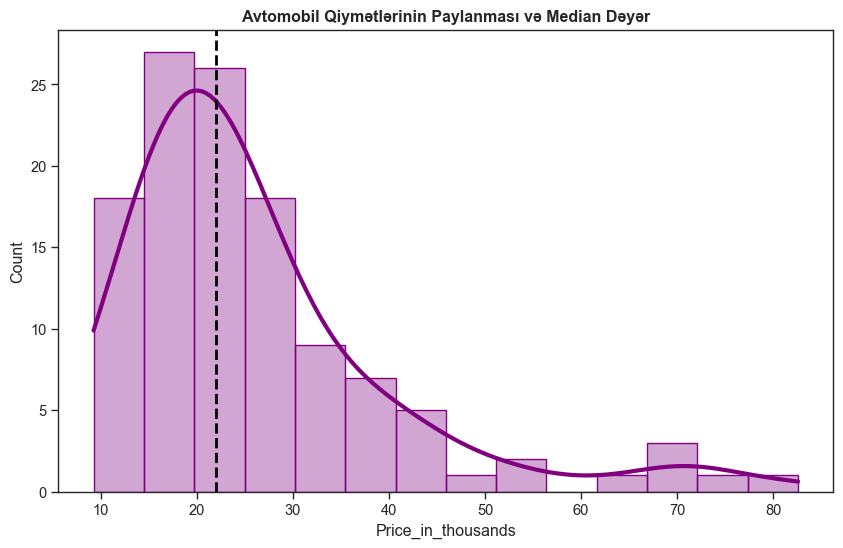

In [6]:
plt.figure(figsize=(10, 6))

# Paylanma qrafikini (histplot + kde) qurun
sns.histplot(data=df, x="Price_in_thousands", kde=True, line_kws=dict(lw=3), ec="purple", lw=1, color="purple", alpha=0.35)

# Median dəyərini tapın və şaquli xətt olaraq əlavə edin (axvline)
median_price = df["Price_in_thousands"].median()
plt.axvline(x=median_price, lw=2, ls="dashed", c="black")

plt.title("Avtomobil Qiymətlərinin Paylanması və Median Dəyər", fontweight='bold')
plt.show()

### Tapşırıq 3: Kateqorik və kəmiyyət dəyişənlərinin kəsişməsi
Bazar seqmentasiyasını təhlil etmək üçün nəqliyyat vasitəsinin növünə (`Vehicle_type` - Məs: Minik, Yolsuzluq) görə qiymət və mühərrik həcmi fərqlərini araşdıracağıq.

**Tələblər:**
- `Seaborn`-un `violinplot` funksiyasından istifadə edərək X oxunda `Vehicle_type`, Y oxunda `Price_in_thousands` dəyişənlərini vizuallaşdırın.
- Skripka qrafiki (violin plot) həm məlumatın paylanma sıxlığını, həm də kvartilləri göstərdiyi üçün mürəkkəb analizlərdə qutu qrafikindən (boxplot) daha məlumatvericidir.

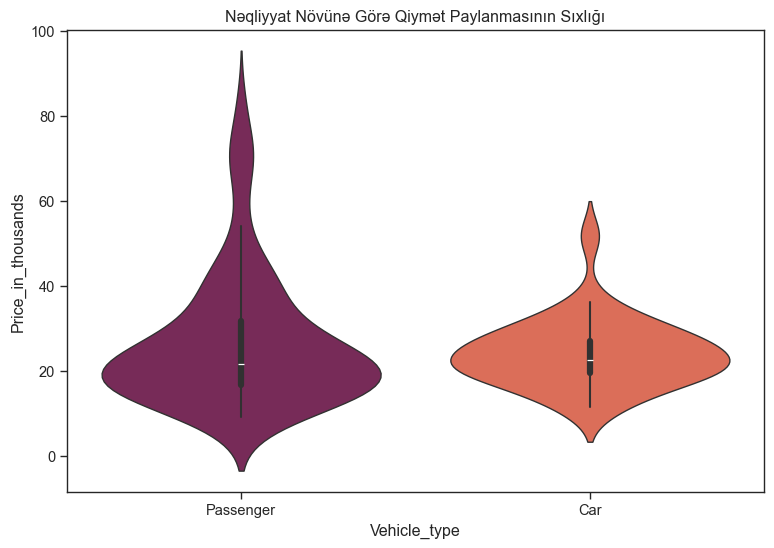

In [7]:
plt.figure(figsize=(9, 6))

# Skripka qrafikini (Violin plot) qurun
sns.violinplot(data=df, x="Vehicle_type", y="Price_in_thousands", hue="Vehicle_type", palette="rocket")

plt.title("Nəqliyyat Növünə Görə Qiymət Paylanmasının Sıxlığı")
plt.show()

### Tapşırıq 4: Enginnering parametrləri arasında xətti və qeyri-xətti asılılıqlar
Avtomobilin mühərrik həcmi (`Engine_size`), at gücü (`Horsepower`) və yanacaq səmərəliliyi (`Fuel_efficiency`) arasındakı fiziki və mühəndislik asılılıqlarını analiz edin.

**Tələblər:**
- X oxunda `Engine_size`, Y oxunda `Fuel_efficiency` olan səpilmə qrafiki (Scatter plot) qurun.
- Nöqtələrin ölçüsünü (size/s) `Horsepower` dəyişəninə görə təyin edin (böyük mühərriklər böyük nöqtələrlə göstərilsin).
- Nöqtələrin rəngini (hue) `Vehicle_type` dəyişəninə görə fərqləndirin.

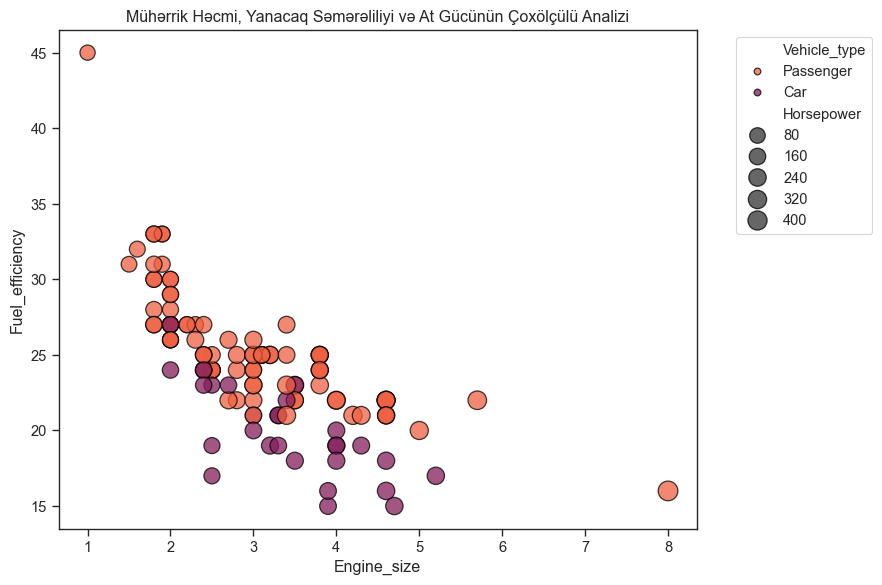

In [8]:
plt.figure(figsize=(9, 6))

# Mürəkkəb səpilmə qrafikini (Scatterplot) qurun (x, y, hue, size parametrləri ilə)
sns.scatterplot(data=df, x="Engine_size", y="Fuel_efficiency", hue="Vehicle_type", size="Horsepower", sizes=(120, 200),
               palette="rocket_r", ec="black", alpha=0.75)

plt.title("Mühərrik Həcmi, Yanacaq Səmərəliliyi və At Gücünün Çoxölçülü Analizi")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Rəng çalarlarının qrafikdən kənarda göstərilməsi
plt.tight_layout()
plt.show()

### Tapşırıq 5: Pearson korrelyasiya matrisinin formal təhlili
Dəyişənlər arasındakı xətti əlaqənin gücünü ölçmək üçün Pearson korrelyasiya əmsalından istifadə edilir. Riyazi olaraq bu əmsal aşağıdakı kimi hesablanır:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

**Tələblər:**
1. `df` daxilindəki yalnız ədədi (numeric) sütunları ayıraraq tam korrelyasiya matrisi yaradın.
2. `Seaborn` istilik xəritəsi (heatmap) ilə bu matrisi vizuallaşdırın.
3. Yalnız korrelyasiya əmsalı $0.5$-dən böyük (müsbət güclü əlaqə) və $-0.5$-dən kiçik (mənfi güclü əlaqə) olan xanaları vurğulamaq üçün qrafikin parametrlərini (`vmin`, `vmax`, `center`) tənzimləyin.

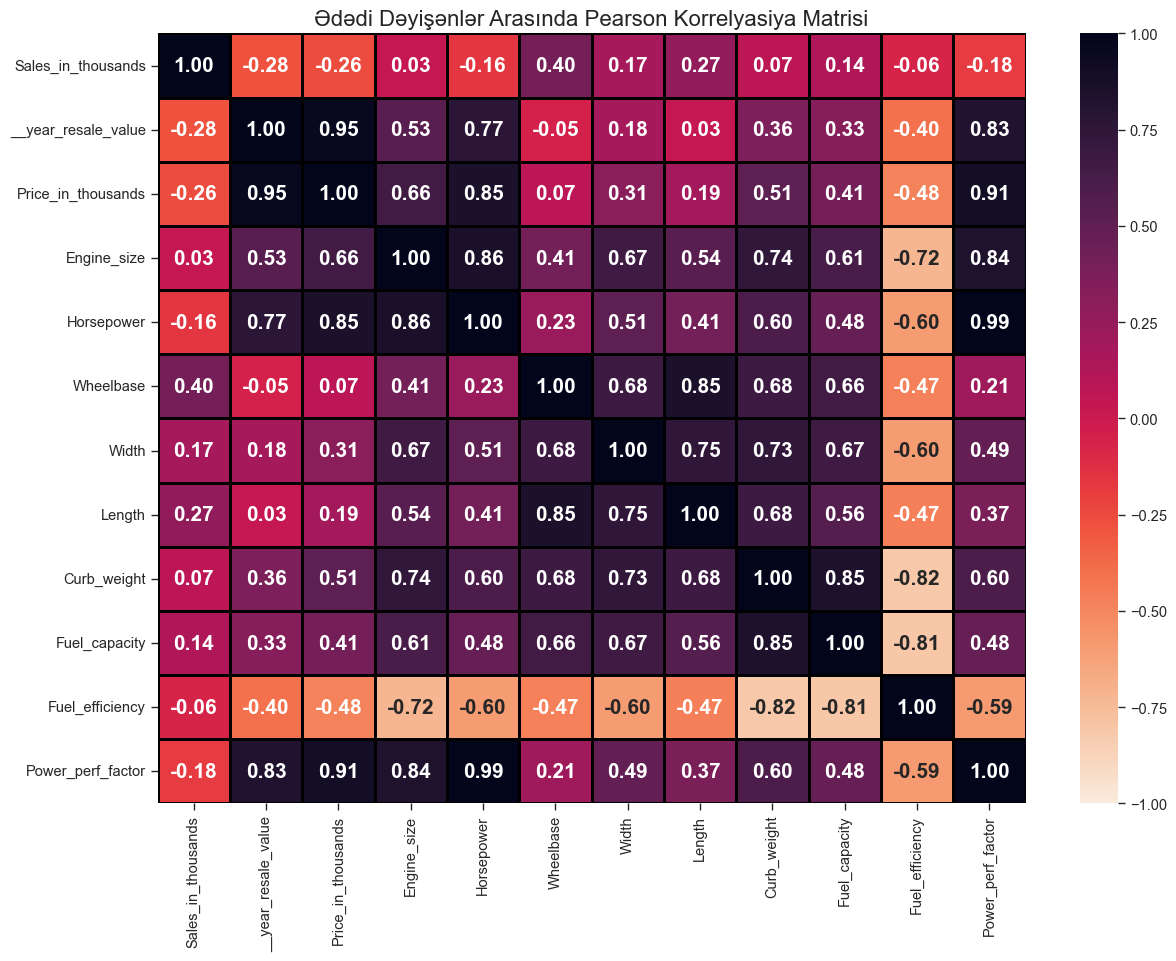

In [9]:
plt.figure(figsize=(14, 10))

# 1. Ədədi dəyişənlərin seçilməsi və korrelyasiya matrisinin hesablanması
corr_matrix = df.corr(method="pearson", numeric_only=True)

# 2. İstilik xəritəsinin qurulması
sns.heatmap(data=corr_matrix, annot=True, fmt=".2f", linecolor="black", linewidths=2,
            annot_kws=dict(size=15, weight="bold"),
            cmap="rocket_r", vmin=-1, vmax=1, center=0)

plt.title("Ədədi Dəyişənlər Arasında Pearson Korrelyasiya Matrisi", fontsize=16)
plt.show()

### Tapşırıq 6: Analitik idarəetmə paneli (Dashboard) - Matplotlib obyekt yönümlü API
Akademik və biznes mühitində hesabat verərkən məlumatı tək bir kompleks paneldə təqdim etmək səmərəliliyi artırır. Matplotlib-in `plt.subplots()` funksiyası ilə 2x2 ölçüsündə qrid (grid) formalaşdırın.

**Tələblər:**
- **Yuxarı Sol (ax[0, 0]):** Ən çox model istehsal edən ilk 10 avtomobil markasını (`Manufacturer`) göstərən üfüqi sütunlu qrafik (Barplot/Countplot).
- **Yuxarı Sağ (ax[0, 1]):** `Horsepower` və `Price_in_thousands` arasındakı asılılıq (Scatter plot + Seaborn `regplot` ilə reqressiya xətti).
- **Aşağı Sol (ax[1, 0]):** Nəqliyyat növünə (`Vehicle_type`) görə yanacaq tutumunun (`Fuel_capacity`) qutu qrafiki (Boxplot).
- **Aşağı Sağ (ax[1, 1]):** Avtomobil çəkisi (`Curb_weight`) ilə təkər bazası (`Wheelbase`) arasındakı əlaqəni göstərən `hexbin` (altıbucaqlı sıxlıq) qrafiki.

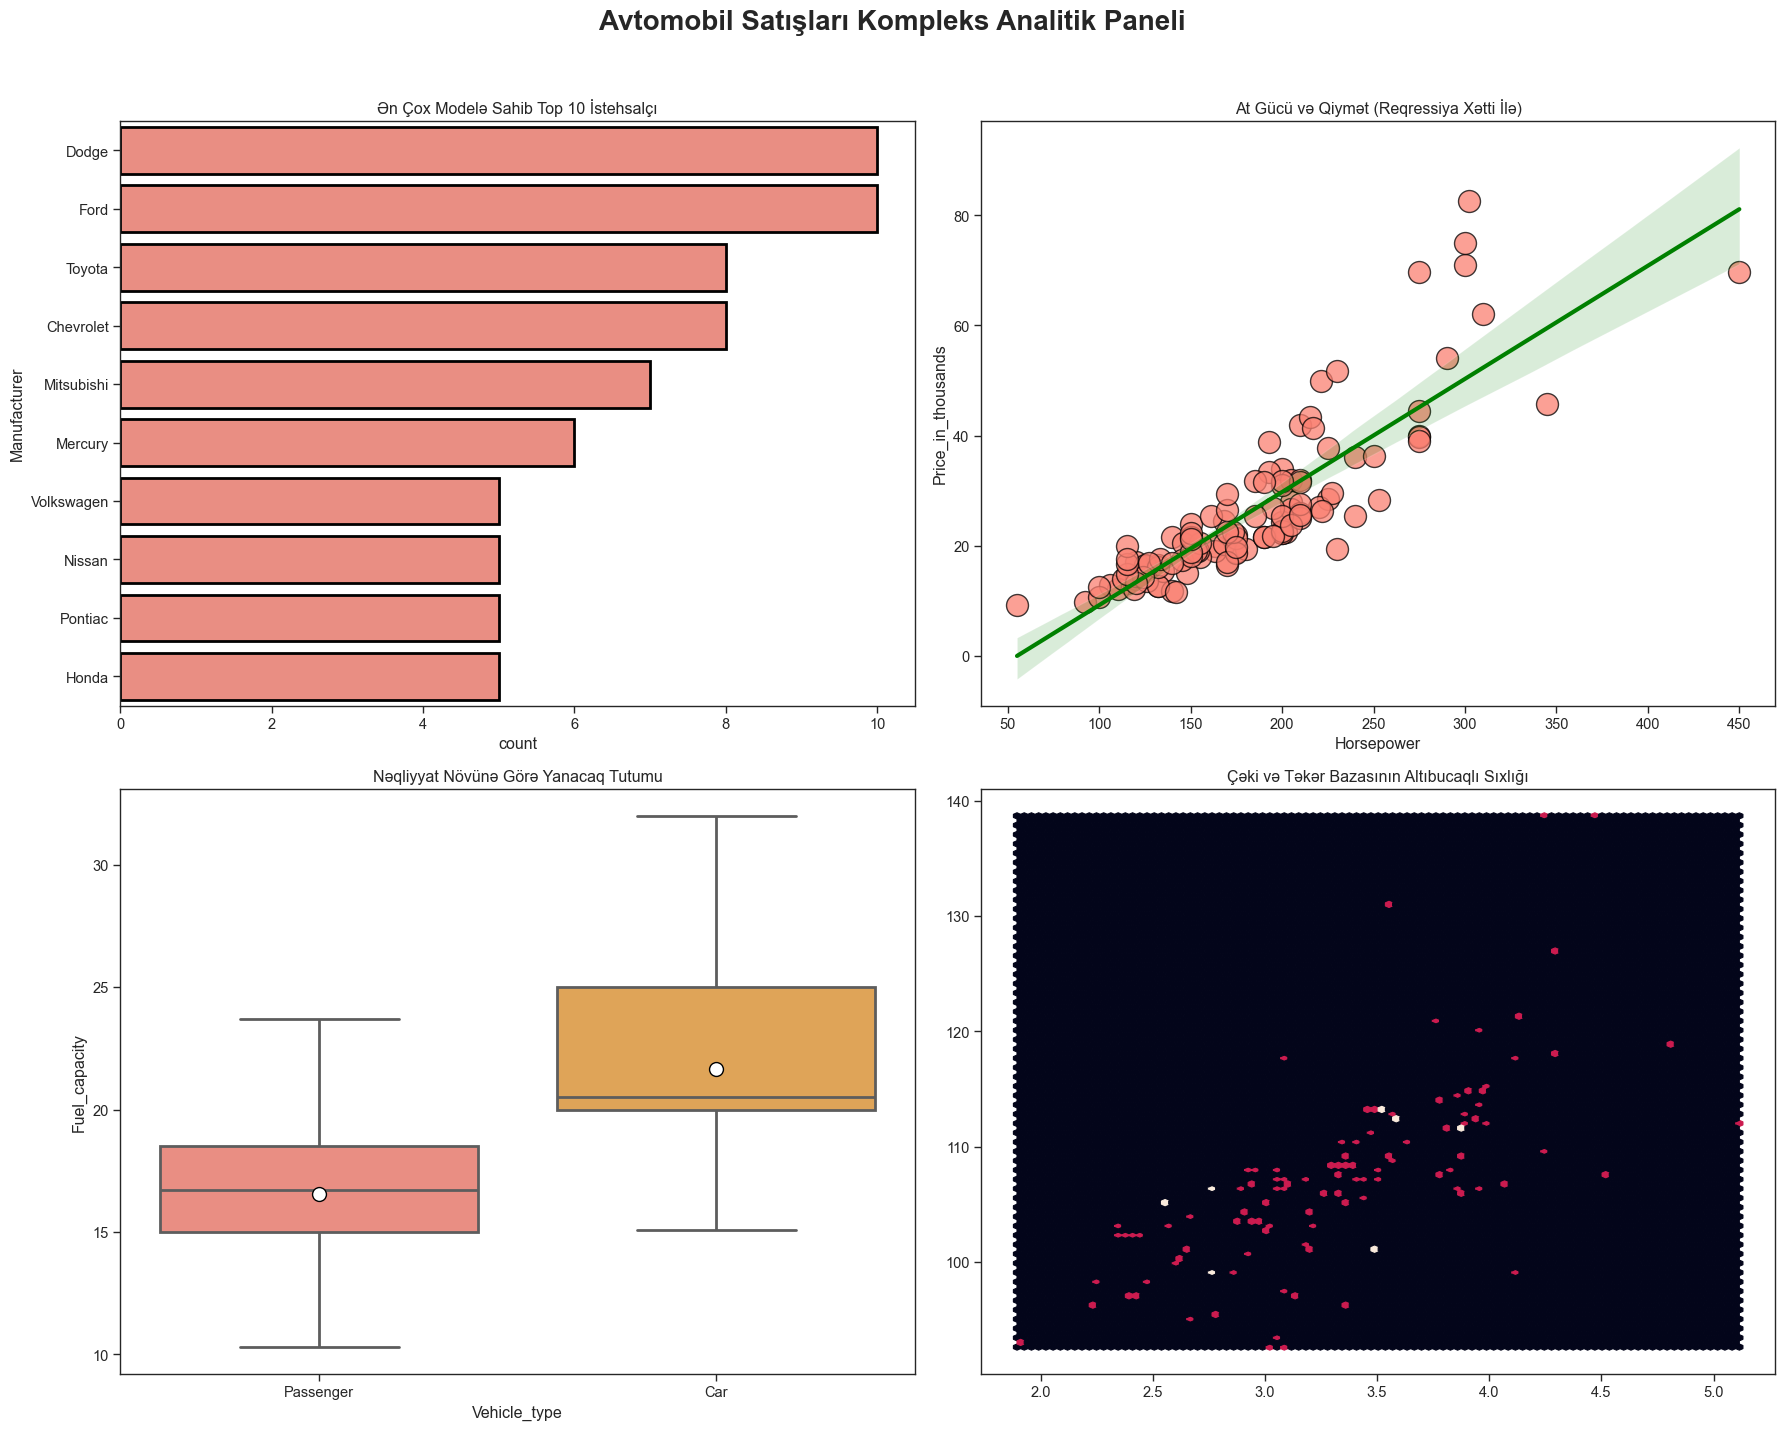

In [54]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
fig.suptitle('Avtomobil Satışları Kompleks Analitik Paneli', fontsize=20, fontweight='bold', y=1.02)

# 1. Yuxarı Sol: Top 10 İstehsalçı
top_10 = df["Manufacturer"].value_counts().index[:10]
sns.countplot(ax=axes[0, 0], data=df, y="Manufacturer", order=top_10, color="salmon", edgecolor="black", lw=2)
axes[0, 0].set_title("Ən Çox Modelə Sahib Top 10 İstehsalçı")

# 2. Yuxarı Sağ: At Gücü və Qiymət Reqressiyası
sns.regplot(ax=axes[0, 1], data=df, x="Horsepower", y="Price_in_thousands", 
            scatter_kws=dict(s=250, ec="black", color="salmon", alpha=0.75),
           line_kws=dict(lw=3, color="green"))
axes[0, 1].set_title("At Gücü və Qiymət (Reqressiya Xətti İlə)")

# 3. Aşağı Sol: Nəqliyyat Növü və Yanacaq Tutumu
sns.boxplot(ax=axes[1, 0], data=df, x="Vehicle_type", y="Fuel_capacity", hue="Vehicle_type", linewidth=2, showmeans=True,
            meanprops={"marker": "o","markerfacecolor": "white","markeredgecolor": "black","markersize": "10"},
            palette=["#FA8072", "#F5A742"])
axes[1, 0].set_title("Nəqliyyat Növünə Görə Yanacaq Tutumu")

# 4. Aşağı Sağ: Çəki və Təkər Bazası (Hexbin Sıxlıq)
axes[1,1].hexbin(x=df["Curb_weight"], y=df["Wheelbase"])
axes[1, 1].set_title("Çəki və Təkər Bazasının Altıbucaqlı Sıxlığı")
plt.hexbin()
plt.tight_layout()
plt.show()

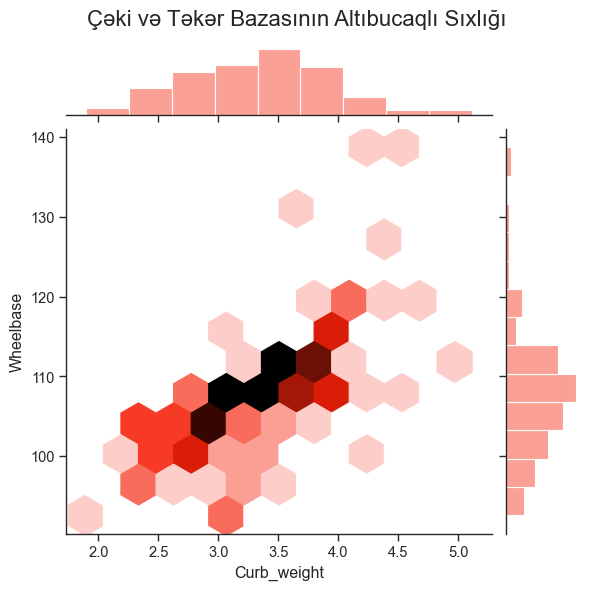

In [83]:
# Additional Graphic for Illustrating Hexbin with Seaborn
main = sns.jointplot(data=df, x="Curb_weight", y="Wheelbase", kind="hex", color="salmon", height=6, ratio=5)
main.fig.suptitle("Çəki və Təkər Bazasının Altıbucaqlı Sıxlığı", fontsize=16)
main.fig.subplots_adjust(top=0.92)
plt.show()